In [10]:
import numpy as np
import pandas as pd
import os
import json
import pathlib
from scipy.stats import gaussian_kde
from tqdm import tqdm
import warnings
import seaborn as sns
from skimage import util
from skimage.filters import threshold_otsu, gaussian, threshold_isodata, threshold_minimum, threshold_triangle, threshold_otsu, threshold_mean, threshold_li, try_all_threshold, threshold_yen, threshold_multiotsu
from skimage.segmentation import clear_border, watershed, expand_labels
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, opening, ball, dilation, erosion
from skimage.transform import rescale
from skimage.feature import peak_local_max
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi
from scipy import stats as _stats
from matplotlib.colors import to_hex
from skimage.filters import median as median_filter
from skimage.morphology import square
from tifffile import imread
import tifffile
import liffile
import napari
from napari.utils.colormaps import DirectLabelColormap
import colorsys
from collections import defaultdict
from skimage.morphology import closing, disk
import contextlib
import joblib
from joblib import Parallel, delayed
from PIL import ImageColor

warnings.filterwarnings("ignore")

@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [11]:
def create_n_valued_palette(base_colour_hex, n=5):
    r, g, b = ImageColor.getcolor(base_colour_hex, "RGB")
    r, g, b = r/255, g/255, b/255
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    adjustments = np.linspace(0.5, 1.4, n)
    palette = []
    for a in adjustments:
        l_adj = min(max(l * a, 0), 1)
        rgb = colorsys.hls_to_rgb(h, l_adj, s)
        palette.append(to_hex(rgb))
    return palette

# Default palette: add/change entries here to introduce new groups
DEFAULT_PALETTE = {
    "ARi": "#FF8C00",
    "UTD": "#000000",
}

In [12]:
def add_experiment_info(df):
    name = str(df["image"]).lower() + str(df["lif_file"]).lower()
    if "fl32" in name:
        df["patient"] = "fl32"
    elif "fl12" in name:
        df["patient"] = "fl12"
    else:
        df["patient"] = "unknown"
    if "day6" in name:
        df["day"] = "6"
    elif "day7" in name:
        df["day"] = "7"
    else:
        df["day"] = "unknown"

    return df

In [13]:
# Canonical regions used throughout
REGIONS = ["chip", "not_chip", "tumour", "chip_not_tumour",
           "chip_vasculature", "chip_not_vasculature", "left", "right"]

def count_cells(region_mask, crow, ccol):
    """Count how many cell centroids (crow, ccol) fall inside region_mask."""
    if len(crow) == 0:
        return 0
    return int(region_mask[crow, ccol].sum())


In [14]:
# ── Label channel convention ──────────────────────────────────────────────────
# Channel 0: chip        (1 = on-chip region)
# Channel 1: vasculature (1 = vasculature)
# Channel 2: b_cells     (1 = B cell)
# Channel 3: cart_cells   (1 = CART cell)
# Channel 4: tumour      (1 = tumour)
LABEL_NAMES = ["chip", "vasculature", "b_cells", "cart_cells", "tumour"]

GAUSS_SIGMAS_UM    = [5, 10, 20, 50, 100]
PROXIMITY_RADII_UM = [5, 10, 20, 30, 40, 50, 100]


def _safe_name(img_name):
    return img_name.replace("/", "_").replace("\\", "_")


def _segment_chip(max_projection):
    """Segment the chip region from the brightfield channel. Returns chip (bool), smoothed."""
    brightfield = max_projection[2]
    clipped = np.clip(brightfield, np.percentile(brightfield, 25), np.percentile(brightfield, 90))
    smoothed = gaussian(clipped, sigma=7)
    bright = smoothed > threshold_li(smoothed)
    labelled_bright = label(bright)
    h = smoothed.shape[0]

    left_labels = set(labelled_bright[:, 0]) - {0}
    left_region = np.isin(labelled_bright, list(left_labels))
    left_region = closing(left_region, disk(10))
    left_region = remove_small_holes(left_region, max_size=500000)

    right_labels = set(labelled_bright[:, -1]) - {0}
    right_region = np.isin(labelled_bright, list(right_labels))
    right_region = closing(right_region, disk(10))
    right_region = remove_small_holes(right_region, max_size=500000)

    if left_region[:, 0].sum() > h / 2:
        bright_mean = smoothed > threshold_mean(smoothed)
        lbl_mean = label(bright_mean)
        ll = set(lbl_mean[:, 0]) - {0}
        left_region = np.isin(lbl_mean, list(ll))
        left_region = closing(left_region, disk(10))
        left_region = remove_small_holes(left_region, max_size=500000)

    if right_region[:, -1].sum() > h / 2:
        bright_mean = smoothed > threshold_mean(smoothed)
        lbl_mean = label(bright_mean)
        rl = set(lbl_mean[:, -1]) - {0}
        right_region = np.isin(lbl_mean, list(rl))
        right_region = closing(right_region, disk(10))
        right_region = remove_small_holes(right_region, max_size=500000)

    chip = (~left_region & ~right_region).astype(bool)
    return chip, smoothed


def _segment_tumour(smoothed, chip):
    """Segment the tumour from the smoothed brightfield, restricted to chip."""
    img_center = np.array([smoothed.shape[0] / 2, smoothed.shape[1] / 2])

    def _best_tumour(lbl_img):
        props = pd.DataFrame(regionprops_table(
            lbl_img, properties=("label", "area", "perimeter", "centroid")))
        props = props[props["area"] >= 0.01 * lbl_img.size] if not props.empty else props
        if props.empty:
            return None
        circ = (4 * np.pi * props["area"]) / (props["perimeter"] ** 2 + 1e-9)
        dist = np.hypot(props["centroid-0"] - img_center[0], props["centroid-1"] - img_center[1])
        props["score"] = props["area"] * circ / (1 + dist)
        return int(props.loc[props["score"].idxmax(), "label"])

    tumour_raw = (smoothed < threshold_triangle(smoothed)) & chip
    lbl = label(tumour_raw)
    chosen = _best_tumour(lbl)
    tumour = (lbl == chosen) if chosen is not None else tumour_raw

    tumour_rp = regionprops(label(tumour))
    if tumour_rp and tumour_rp[0].solidity < 0.9:
        eroded = erosion(tumour, disk(10))
        e_lbl = label(eroded)
        chosen_e = _best_tumour(e_lbl)
        if chosen_e is not None:
            tumour = (expand_labels(e_lbl, distance=10) == chosen_e)

        tumour_rp = regionprops(label(tumour))
        if tumour_rp and tumour_rp[0].solidity < 0.9:
            eroded = erosion(tumour, disk(50))
            e_lbl = label(eroded)
            chosen_e = _best_tumour(e_lbl)
            if chosen_e is not None:
                tumour = (expand_labels(e_lbl, distance=60) == chosen_e)

    # Watershed: split tumour into ≤2 sub-regions, keep the darkest
    tumour_mask = tumour.astype(bool)
    tumour_mask = remove_small_holes(tumour_mask, max_size=500000)
    tumour_pixels = smoothed[tumour_mask]
    if tumour_pixels.size > 0:
        smooth_for_ws = gaussian(smoothed, sigma=10)
        edt_tumour = distance_transform_edt(tumour_mask)
        coords = peak_local_max(edt_tumour, min_distance=60,
                                labels=tumour_mask.astype(int), num_peaks=2)
        if len(coords) >= 2:
            markers = np.zeros_like(tumour_mask, dtype=int)
            for i, (r, c) in enumerate(coords, start=1):
                markers[r, c] = i
            ws_labels = watershed(smooth_for_ws, markers, mask=tumour_mask)
            ws_medians = {}
            for lbl_val in np.unique(ws_labels[ws_labels > 0]):
                ws_medians[lbl_val] = float(np.median(smoothed[ws_labels == lbl_val]))
            darkest_label = min(ws_medians, key=ws_medians.get)
            tumour = (ws_labels == darkest_label)
        else:
            tumour = tumour_mask

    return tumour.astype(bool)


# ══════════════════════════════════════════════════════════════════════════════
# STEP 1: Segment and save raw + labels + metadata
# ══════════════════════════════════════════════════════════════════════════════
def segment_and_save(img, output_dir, lif_path=None):
    """Project to 2D, auto-segment, save raw channels + label masks + metadata as TIFs/JSON."""
    output_dir = pathlib.Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)
    safe = _safe_name(img.name)

    lif_stem = lif_path.stem if lif_path else ""
    combined = (img.name + lif_stem).lower()
    meta = {
        "image_name": img.name,
        "lif_file": lif_stem,
        "patient": "fl32" if "fl32" in combined else "fl12" if "fl12" in combined else "unknown",
        "day": "6" if "day6" in combined else "7" if "day7" in combined else "unknown",
    }

    # Max projection
    max_projection = np.max(img.asarray(), axis=img.dims.index('Z'))  # (C, Y, X)

    # Pixel size
    try:
        x_coords = img.coords["X"]
        um_per_px = abs(float(x_coords[1] - x_coords[0])) * 1e6
        if um_per_px <= 0:
            raise ValueError
    except Exception:
        um_per_px = 1.0
        warnings.warn(f"Could not read pixel size for {img.name}, using 1 µm/px")
    meta["um_per_px"] = um_per_px

    # Cell segmentation (binary — all cells of one type share same label value)
    bcells_raw = max_projection[0]
    cart_raw = max_projection[-1]
    seg_b = (bcells_raw > threshold_yen(bcells_raw)).astype(np.uint8)
    seg_cart = (cart_raw > threshold_yen(cart_raw)).astype(np.uint8)

    # Vasculature
    vasc_raw = max_projection[1]
    vasc_med = median_filter(vasc_raw, footprint=square(7))
    vasc_sm = gaussian(vasc_med, sigma=3)
    seg_vasc = vasc_sm > threshold_triangle(vasc_sm)
    lbl_vasc = label(seg_vasc)
    rp = pd.DataFrame(regionprops_table(lbl_vasc, properties=("area", "solidity")))
    if float(rp.loc[rp["area"].idxmax(), "solidity"]) > 0.9:
        seg_vasc = vasc_sm > threshold_li(vasc_sm)
    seg_vasc = seg_vasc.astype(np.uint8)

    # Chip
    chip, smoothed = _segment_chip(max_projection)
    seg_chip = chip.astype(np.uint8)

    # Tumour
    seg_tumour = _segment_tumour(smoothed, chip).astype(np.uint8)

    # Stack labels: (5, Y, X) uint8  — channels: chip, vasculature, b_cells, cart_cells, tumour
    labels = np.stack([seg_chip, seg_vasc, seg_b, seg_cart, seg_tumour], axis=0)

    # Save
    tifffile.imwrite(str(output_dir / f"{safe}_raw.tif"),
                     max_projection.astype(np.float32), imagej=True)
    tifffile.imwrite(str(output_dir / f"{safe}_labels.tif"),
                     labels, imagej=True)
    with open(output_dir / f"{safe}_meta.json", "w") as f:
        json.dump(meta, f, indent=2)

    print(f"  Saved: {safe}")
    return safe


# ══════════════════════════════════════════════════════════════════════════════
# STEP 2: Open all images + labels in Napari for manual correction
# ══════════════════════════════════════════════════════════════════════════════
LABEL_COLORMAPS = {
    "chip":        DirectLabelColormap(color_dict={0: "transparent", 1: "cyan"}),
    "vasculature": DirectLabelColormap(color_dict={0: "transparent", 1: "magenta"}),
    "b_cells":     DirectLabelColormap(color_dict={0: "transparent", 1: "green"}),
    "cart_cells":  DirectLabelColormap(color_dict={0: "transparent", 1: "red"}),
    "tumour":      DirectLabelColormap(color_dict={0: "transparent", 1: "yellow"}),
}

def review_in_napari(label_dir):
    """Load ONE image at a time into Napari for editing.

    Returns (viewer, controls) where controls has .next(), .prev(), .save(), .goto(i).
    Only the current image's layers are in memory at any time.
    """
    from magicgui import magicgui
    from napari._qt.qthreading import thread_worker
    label_dir = pathlib.Path(label_dir)

    # Discover all image sets
    raw_files = sorted(label_dir.glob("*_raw.tif"))
    image_list = []
    for raw_path in raw_files:
        safe = raw_path.stem.replace("_raw", "")
        labels_path = label_dir / f"{safe}_labels.tif"
        if labels_path.exists():
            image_list.append((safe, raw_path, labels_path))

    if not image_list:
        print("No images found in", label_dir)
        return None, None

    viewer = napari.Viewer()
    state = {"idx": 0, "label_layers": {}, "all_labels": None, "dirty": False}

    CH_NAMES = ["B cells (raw)", "Vasculature (raw)", "Brightfield", "CART (raw)"]
    EDITABLE_LABELS = ["chip", "tumour"]  # only these get viewer layers

    def _save_current():
        if not state["label_layers"] or state["all_labels"] is None:
        if not state["label_layers"]:
            return
        updated = state["all_labels"].copy()
        for lname, layer in state["label_layers"].items():
            li = LABEL_NAMES.index(lname)
            updated[li] = (layer.data > 0).astype(np.uint8)
        tifffile.imwrite(str(labels_path), updated.astype(np.uint8), imagej=True)
        state["dirty"] = False
        print(f"  Saved: {labels_path.name}")

    def _load_image(idx):
        """Clear viewer and load image at index idx."""
        # Auto-save previous if dirty
        if state["dirty"]:
            _save_current()

        state["label_layers"] = {}
        viewer.layers.clear()
        state["label_layers"] = []

        safe, raw_path, labels_path = image_list[idx]
        state["idx"] = idx

        state["all_labels"] = labels_arr.copy()

        # Raw channels (not editable)
        for ci in range(raw.shape[0]):
            name = CH_NAMES[ci] if ci < len(CH_NAMES) else f"Ch{ci}"
            viewer.add_image(raw[ci], name=name,
                             visible=(ci == 2), blending="additive")

        # Editable label layers (chip + tumour only)
        for lname in EDITABLE_LABELS:
            li = LABEL_NAMES.index(lname)
            layer = viewer.add_labels(
                labels_arr[li],
                name=lname,
                colormap=LABEL_COLORMAPS.get(lname),
            )
            state["label_layers"][lname] = layer

        viewer.title = f"[{idx + 1}/{len(image_list)}] {safe}"
        state["dirty"] = True  # mark dirty once loaded (will save on navigate)
        print(f"Loaded [{idx + 1}/{len(image_list)}]: {safe}")

    def _fn_save():
        _save_current()

    def _fn_next():
        if state["idx"] < len(image_list) - 1:
            _load_image(state["idx"] + 1)
        else:
            print("Already at last image.")

    def _fn_prev():
        if state["idx"] > 0:
            _load_image(state["idx"] - 1)
        else:
            print("Already at first image.")

    def _fn_goto(i):
        if 0 <= i < len(image_list):
            _load_image(i)
        else:
            print(f"Index {i} out of range (0–{len(image_list)-1})")
        """Replace a label layer with a fresh blank one."""
        if name not in EDITABLE_LABELS:
            print(f"Unknown label '{name}'. Choose from: {EDITABLE_LABELS}")
            return
        old_layer = state["label_layers"][name]
        shape = old_layer.data.shape

        viewer.layers.remove(old_layer)

        blank = np.zeros(shape, dtype=old_layer.data.dtype)
        new_layer = viewer.add_labels(
            blank,
            name=name,
            colormap=LABEL_COLORMAPS.get(name),
        )
        state["label_layers"][name] = new_layer
        state["dirty"] = True
        print(f"  Reset '{name}' to blank. Paint with value 1 to redraw.")

    # Keyboard shortcuts
    @viewer.bind_key("n")
    def _key_next(viewer):
        _fn_next()

    @viewer.bind_key("b")
    def _key_prev(viewer):
        _fn_prev()

    @viewer.bind_key("Control-s")
    def _key_save(viewer):
        _fn_save()

    # Load first image
    _load_image(0)
    print(f"\n{len(image_list)} images found. Shortcuts: n=next, b=back, Ctrl+S=save")
    print("Labels auto-save when you navigate to the next/prev image.")

    class _Controls:
        """Returned handle for programmatic navigation."""
    # Reset-label button (docked in viewer)
    @magicgui(
        call_button="Reset Label",
        label_name={"choices": EDITABLE_LABELS, "label": "Label to reset"},
    )
    def reset_widget(label_name=EDITABLE_LABELS[0]):
        _fn_reset_label(label_name)

    viewer.window.add_dock_widget(reset_widget, name="Reset Label", area="right")

    # Load first image
    _load_image(0)
    print(f"\n{len(image_list)} images found. Shortcuts: n=next, b=back, Ctrl+S=save")
    print("Labels auto-save when you navigate to the next/prev image.")

    class _Controls:
        """Returned handle for programmatic navigation."""
        next = staticmethod(_fn_next)
        prev = staticmethod(_fn_prev)
        save = staticmethod(_fn_save)
        goto = staticmethod(_fn_goto)
        reset_label = staticmethod(_fn_reset_label)
        n_images = len(image_list)

    return viewer, _Controls()
        labels_path = label_dir / f"{safe}_labels.tif"

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3: Analyse from corrected labels
# ══════════════════════════════════════════════════════════════════════════════
def analyse_from_labels(label_dir, output_folder):
    """Load corrected labels, recompute left/right, run counting + colocalisation."""
    label_dir = pathlib.Path(label_dir)
    output_folder = pathlib.Path(output_folder)
    output_folder.mkdir(exist_ok=True, parents=True)

    all_records, all_dists, all_coloc = [], [], []

    meta_files = sorted(label_dir.glob("*_meta.json"))
    for meta_path in tqdm(meta_files, desc="Analysing corrected labels"):
        safe = meta_path.stem.replace("_meta", "")
        raw_path = label_dir / f"{safe}_raw.tif"
        labels_path = label_dir / f"{safe}_labels.tif"

        with open(meta_path) as f:
            meta = json.load(f)

        raw = tifffile.imread(str(raw_path))          # (C, Y, X)
        labels_arr = tifffile.imread(str(labels_path))  # (5, Y, X)
        um_per_px = meta.get("um_per_px", 1.0)

        # Unpack label channels
        chip     = labels_arr[0].astype(bool)
        vasc     = labels_arr[1].astype(bool)
        seg_b    = labels_arr[2].astype(bool)
        seg_cart = labels_arr[3].astype(bool)
        tumour   = labels_arr[4].astype(bool)

        # Recompute left/right from chip
        not_chip = ~chip
        lbl_nc = label(not_chip)
        left_mask = np.zeros_like(chip)
        right_mask = np.zeros_like(chip)
        for rp in regionprops(lbl_nc):
            coords = rp.coords  # (N, 2) — row, col
            if np.any(coords[:, 1] == 0):
                left_mask[lbl_nc == rp.label] = True
            if np.any(coords[:, 1] == chip.shape[1] - 1):
                right_mask[lbl_nc == rp.label] = True

        # Build regions dict
        regions = {
            "chip":                 chip,
            "not_chip":             not_chip,
            "tumour":               chip & tumour,
            "chip_not_tumour":      chip & ~tumour,
            "chip_vasculature":     chip & vasc,
            "chip_not_vasculature": chip & ~vasc,
            "left":                 left_mask.astype(bool),
            "right":                right_mask.astype(bool),
        }

        dist_from_tumour = distance_transform_edt(~tumour)
        img_name = meta["image_name"]
        m = {k: meta[k] for k in ("lif_file", "patient", "day")}

        # Counting
        records, dist_records = [], []
        for cell_name, cell_mask in [("CART cells", seg_cart), ("B cells", seg_b)]:
            labelled_cells = label(cell_mask)
            total_cells = int(labelled_cells.max())
            total_pixels = int(cell_mask.sum())
                records.append(dict(**m, image=img_name, cell_type=cell_name,
            if total_cells > 0:
                cprops = pd.DataFrame(regionprops_table(labelled_cells, properties=("centroid",)))
                crow = np.clip(np.round(cprops["centroid-0"].values).astype(int),
                               0, cell_mask.shape[0] - 1)
                ccol = np.clip(np.round(cprops["centroid-1"].values).astype(int),
                               0, cell_mask.shape[1] - 1)
            else:
                crow = np.array([], dtype=int)
                ccol = np.array([], dtype=int)
                        rec[f"in_{rname}"] = bool(rmask[r, c])
            records.append(dict(**m, image=img_name, cell_type=cell_name,
                                region="overall", cell_count=total_cells,
                                positive_pixels=total_pixels))
            for rname, rmask in regions.items():
                n_cells = count_cells(rmask, crow, ccol)
                n_px = int(np.sum(cell_mask & rmask))
                records.append(dict(**m, image=img_name, cell_type=cell_name,
                                    region=rname, cell_count=n_cells,
                                    positive_pixels=n_px))

            if total_cells > 0:
                dists = dist_from_tumour[crow, ccol] * um_per_px
                for r, c, d in zip(crow, ccol, dists):
                    rec = dict(**m, image=img_name, cell_type=cell_name,
                               distance_from_tumour_um=float(d))
                    for rname, rmask in regions.items():
                        rec[f"in_{rname}"] = bool(rmask[r, c])
                    dist_records.append(rec)

        # Colocalisation
        bcell_float = raw[0].astype(float)
        cart_float = raw[-1].astype(float)
        coloc_records = []
            for rname, rmask in regions.items():
        for sigma_um in GAUSS_SIGMAS_UM:
            sigma_px = sigma_um / um_per_px
            b_blur = gaussian(bcell_float, sigma=sigma_px)
            c_blur = gaussian(cart_float, sigma=sigma_px)
            for rname, rmask in regions.items():
                bv, cv = b_blur[rmask], c_blur[rmask]
                r_val = np.nan if len(bv) < 20 else float(_stats.pearsonr(bv, cv)[0])
                coloc_records.append(dict(**m, image=img_name, method="coarse_pearson",
                                          param_um=sigma_um, region=rname, score=r_val))

        cart_edt = distance_transform_edt(~seg_cart)
        b_edt = distance_transform_edt(~seg_b)
        for radius_um in PROXIMITY_RADII_UM:
            radius_px = radius_um / um_per_px
            cart_within = cart_edt <= radius_px
            b_within = b_edt <= radius_px
            for rname, rmask in regions.items():
                b_in = seg_b & rmask;  n_b = int(b_in.sum())
                c_in = seg_cart & rmask; n_c = int(c_in.sum())
                frac_b = float((b_in & cart_within).sum()) / n_b if n_b else np.nan
                frac_c = float((c_in & b_within).sum()) / n_c if n_c else np.nan
                coloc_records.append(dict(**m, image=img_name, method="B_near_CART",
                                          param_um=radius_um, region=rname, score=frac_b))
                coloc_records.append(dict(**m, image=img_name, method="CART_near_B",
                                          param_um=radius_um, region=rname, score=frac_c))

        all_records.append(pd.DataFrame(records))
        all_dists.append(pd.DataFrame(dist_records))
        all_coloc.append(pd.DataFrame(coloc_records))
    all_results = pd.concat(all_records, ignore_index=True)
    return all_results, all_distances, coloc_df
    return all_results, all_distances, coloc_df

    all_distances = pd.concat(all_dists, ignore_index=True)    coloc_df.to_csv(output_folder / "all_colocalisation.csv", index=False)

    coloc_df = pd.concat(all_coloc, ignore_index=True)    all_distances.to_csv(output_folder / "all_distances.csv", index=False)

    all_results.to_csv(output_folder / "all_counts.csv", index=False)

IndentationError: expected an indented block after 'if' statement on line 229 (1807296898.py, line 230)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Segment all images and save raw + labels + metadata
# ══════════════════════════════════════════════════════════════════════════════
lif_folder = pathlib.Path(r"Z:\Marina\Stellaris\2026.04.01_CART_setup\Bel")
label_dir = lif_folder / "labels"

lif_files = sorted(lif_folder.glob("*.lif"))
print(f"Found {len(lif_files)} LIF files in {lif_folder}")
for lf in lif_files:
    print(f"  {lf.name}")

# Build task list
tasks = []
for lif_path in lif_files:
    with liffile.LifFile(lif_path) as lif:
        print(f"  {lif_path.name}: {len(lif.images)} images")
        for idx in range(len(lif.images)):
            tasks.append((lif_path, idx))

def _process_one(lif_path, img_idx):
    with liffile.LifFile(lif_path) as lif:
        img = lif.images[img_idx]
        return segment_and_save(img, label_dir, lif_path=lif_path)

with tqdm_joblib(tqdm(desc="Segmenting images", total=len(tasks))) as pbar:
    results = Parallel(n_jobs=4, prefer="threads")(
        delayed(_process_one)(lif_path, idx) for lif_path, idx in tasks
    )

print(f"\nAll labels saved to: {label_dir}")

Found 3 LIF files in Z:\Marina\Stellaris\2026.04.01_CART_setup\Bel
  2026.04.01_CART.lif
  2026.04.04_CART.lif
  CART_fixed_day8_9.lif
  2026.04.01_CART.lif: 28 images
  2026.04.04_CART.lif: 16 images
  CART_fixed_day8_9.lif: 7 images


Segmenting images:   2%|▏         | 1/51 [00:59<49:30, 59.42s/it]

  Saved: Day6_Plate2_UTD_7mm_Merged


Segmenting images:   4%|▍         | 2/51 [02:29<1:03:16, 77.47s/it]

  Saved: Day6_Plate2_ARi_7mm_Merged


...

  Saved: Day9_Plate3_UTD_7mm_Merged


Segmenting images:  98%|█████████▊| 50/51 [21:33<00:21, 21.17s/it]

  Saved: Day9_Plate3_ARi_7mm_Merged


Segmenting images: 100%|██████████| 51/51 [23:27<00:00, 27.59s/it]

  Saved: Day9_Plate3_UTD_3mm_Merged

All labels saved to: Z:\Marina\Stellaris\2026.04.01_CART_setup\Bel\labels


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Open labels in Napari, edit, then save
# ══════════════════════════════════════════════════════════════════════════════
# Loads ONE image at a time to avoid freezing.
# Shortcuts: n = next image, b = previous image, Ctrl+S = save current
# Labels auto-save when you navigate to the next/prev image.
# You can also call:  controls.next()  controls.prev()  controls.save()  controls.goto(i)

label_dir = pathlib.Path(r"Z:\Marina\Stellaris\2026.04.01_CART_setup\Bel\labels\test")
viewer, controls = review_in_napari(label_dir)

Loaded [1/5]: Day8_Plate6_UTD_3mm_Merged

5 images found. Shortcuts: n=next, b=back, Ctrl+S=save
Labels auto-save when you navigate to the next/prev image.


NameError: name 'save' is not defined

  Saved: Day8_Plate6_UTD_3mm_Merged_labels.tif
Loaded [2/5]: Day8_Plate6_UTD_7mm_Merged
  Saved: Day8_Plate6_UTD_7mm_Merged_labels.tif
Loaded [3/5]: Day9_Plate3_ARi_7mm_Merged


In [ ]:
# Save the current image's labels (also happens automatically when navigating)
controls.save()

(252, 9)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Analyse from corrected labels
# ══════════════════════════════════════════════════════════════════════════════
label_dir = pathlib.Path(r"Z:\Marina\Stellaris\2026.04.01_CART_setup\Bel\labels")
output_folder = pathlib.Path(r"Z:\Marina\Stellaris\2026.04.01_CART_setup\Bel\output_figures")

all_results, all_distances, coloc_df = analyse_from_labels(label_dir, output_folder)

# Add experiment labels
for df in [all_results, all_distances, coloc_df]:
    df["experiment"] = df["image"].astype(str).str.contains("ARi", case=False, na=False).map({True: "ARi", False: "UTD"})

print(f"all_results:   {len(all_results)} rows")
print(f"all_distances: {len(all_distances)} rows")
print(f"coloc_df:      {len(coloc_df)} rows")

In [ ]:
# ── Plotting helpers ───────────────────────────────────────────────────────────
def _build_img_color(df, group_col="experiment", palette_map=None):
    if palette_map is None:
        palette_map = DEFAULT_PALETTE
    images = df["image"].unique()
    img_color = {}
    group_images = {}
    group_base_colors = {}

    for group_name, base_hex in palette_map.items():
        grp_imgs = df.loc[df[group_col] == group_name, "image"].unique().tolist()
        if not grp_imgs:
            continue
        shades = create_n_valued_palette(base_hex, max(len(grp_imgs), 2))
        for k, img_name in enumerate(grp_imgs):
            img_color[img_name] = shades[k % len(shades)]
        group_images[group_name] = grp_imgs
        group_base_colors[group_name] = base_hex

    for img_name in images:
        if img_name not in img_color:
            img_color[img_name] = "gray"
    return img_color, group_images, group_base_colors


def _scatter_and_record(ax, data, x_col, y_col, order, img_color):
    positions = {}
    group_pts = defaultdict(list)
    for _, row in data.iterrows():
        group_pts[row[x_col]].append(row)
    for gi, grp_name in enumerate(order):
        rows = group_pts.get(grp_name, [])
        jitter = np.linspace(-0.15, 0.15, max(len(rows), 1))
        for ri, row in enumerate(rows):
            x_pos = gi + jitter[ri]
            y_pos = row[y_col]
            c = img_color.get(row["image"], "gray")
            ax.scatter(x_pos, y_pos, color=c,
                       s=40, edgecolor="white", linewidth=0.4, zorder=3)
            positions[(grp_name, row["image"])] = (x_pos, y_pos, c)
    return positions


def _draw_pair_lines_from_positions(ax, positions, pairs):
    for in_grp, out_grp in pairs:
        for key, (x_in, y_in, c) in positions.items():
            if key[0] != in_grp:
                continue
            out_key = (out_grp, key[1])
            if out_key not in positions:
                continue
            x_out, y_out, _ = positions[out_key]
            ax.plot([x_in, x_out], [y_in, y_out],
                    color=c, lw=0.9, alpha=0.45, zorder=0)


def plot_swarmplots(df, save_title, title_suffix="", group_col="experiment",
                    palette_map=None, plot_regions=None):
    img_color, group_images, group_base_colors = _build_img_color(df, group_col, palette_map)

    if plot_regions is None:
        plot_regions = REGIONS
    metrics = [("cell_count", "Cell count"), ("positive_pixels", "Positive pixels")]
    cell_order = ["CART cells", "B cells"]
    cell_pairs = [("CART cells", "B cells")]

    for metric, ylabel in metrics:
        n_panels = len(plot_regions)
        fig, axes = plt.subplots(1, n_panels, figsize=(3.5 * n_panels, 5),
                                 sharey=True, constrained_layout=True)
        fig.suptitle(f"{ylabel}{title_suffix}", fontsize=12, fontweight="bold")
        if n_panels == 1:
            axes = [axes]

        for ax, region in zip(axes, plot_regions):
            sub = df[df.region == region].copy()
            sub["group"] = sub["cell_type"]
            pos = _scatter_and_record(ax, sub, "group", metric, cell_order, img_color)
            _draw_pair_lines_from_positions(ax, pos, cell_pairs)
            ax.set_xticks(range(len(cell_order)))
            ax.set_xticklabels(cell_order, fontsize=8)
            ax.set_title(region, fontsize=10)
            ax.set_xlabel("")
            ax.set_ylabel(ylabel if ax is axes[0] else "")

        legend_handles = []
        for grp_name, imgs in group_images.items():
            for img_name in imgs:
                legend_handles.append(plt.Line2D(
                    [0], [0], marker="o", color="w",
                    markerfacecolor=img_color[img_name], markersize=6,
                    label=f"{img_name} ({grp_name})"))
        fig.legend(handles=legend_handles[:15], loc="outside right upper", fontsize=7, ncol=1)
        plt.savefig(f"{save_title}_{metric}.png")
        plt.show()


def plot_distance_kde(df, save_title, title_suffix="", group_col="experiment", palette_map=None):
    if df.empty:
        print(f"No data for{title_suffix} — skipping.")
        return
    img_color, group_images, group_base_colors = _build_img_color(df, group_col, palette_map)
    cell_types = df["cell_type"].unique()
    imgs = df["image"].unique()

    fig, axes = plt.subplots(1, len(cell_types), figsize=(7 * len(cell_types), 4),
                             sharey=False, constrained_layout=True)
    if len(cell_types) == 1:
        axes = [axes]

    x_grid = np.linspace(0, df["distance_from_tumour_um"].max(), 500)

    for ax, ct in zip(axes, cell_types):
        sub_ct = df[df["cell_type"] == ct]
        group_densities = {g: [] for g in group_base_colors}

        for img_name in imgs:
            vals = sub_ct[sub_ct["image"] == img_name]["distance_from_tumour_um"].values
            if len(vals) < 2:
                continue
            kde = gaussian_kde(vals)
            y = kde(x_grid)
            c = img_color.get(img_name, "gray")
            ax.plot(x_grid, y, color=c, alpha=0.5, linewidth=1.2, label=img_name)
            for grp_name, grp_imgs in group_images.items():
                if img_name in grp_imgs:
                    group_densities[grp_name].append(y)
                    break

        for grp_name, densities in group_densities.items():
            if densities:
                mean_y = np.mean(densities, axis=0)
                ax.plot(x_grid, mean_y,
                        color=group_base_colors[grp_name], linewidth=2.5,
                        linestyle="--", label=f"Mean {grp_name}")
                if len(densities) > 1:
                    sd_y = np.std(densities, axis=0)
                    ax.fill_between(x_grid, mean_y - sd_y, mean_y + sd_y,
                                    color=group_base_colors[grp_name], alpha=0.15,
                                    label=f"±1 SD {grp_name}")

        ax.set_title(ct, fontsize=11, fontweight="bold")
        ax.set_xlabel("Distance from tumour edge (µm)", fontsize=9)
        ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=7, ncol=1)

    fig.suptitle(f"Distance from tumour edge{title_suffix}",
                 fontsize=11, fontweight="bold")
    plt.savefig(f"{save_title}.pdf")
    plt.show()


ALL_COLOC_METHODS = ["coarse_pearson", "B_near_CART", "CART_near_B"]
COLOC_YLABELS = {
    "coarse_pearson": "Pearson r (blurred channels)",
    "B_near_CART":    "Fraction of B cells near a CART cell",
    "CART_near_B":    "Fraction of CART cells near a B cell",
}

def plot_colocalisation(df, save_title, title_suffix="", group_col="experiment", palette_map=None,
                        methods=None, plot_regions=None):
    if methods is None:
        methods = ALL_COLOC_METHODS
    if plot_regions is None:
        plot_regions = REGIONS
    img_color, group_images, group_base_colors = _build_img_color(df, group_col, palette_map)

    images = df["image"].unique()
    n_rows = len(methods)
    n_cols = len(plot_regions)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4 * n_cols, 4 * n_rows),
                             constrained_layout=True)
    fig.suptitle(f"Colocalisation — B cells ↔ CART cells{title_suffix}",
                 fontsize=11, fontweight="bold")

    if n_rows == 1:
        axes = axes[np.newaxis, :]
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    for row, method in enumerate(methods):
        sub_m = df[df.method == method]
        for col, region in enumerate(plot_regions):
            ax = axes[row, col]
            sub = sub_m[sub_m.region == region].copy()

            for img_name in images:
                s = sub[sub.image == img_name].sort_values("param_um")
                c = img_color.get(img_name, "gray")
                ax.plot(s["param_um"], s["score"],
                        color=c, alpha=0.7, linewidth=1,
                        label=img_name, linestyle="dashdot")

            for grp_name, base_color in group_base_colors.items():
                mean_grp = (sub[sub[group_col] == grp_name]
                            .groupby("param_um")["score"].mean().reset_index())
                std_grp = (sub[sub[group_col] == grp_name]
                           .groupby("param_um")["score"].std().reset_index()
                           .rename(columns={"score": "sd"}))
                if not mean_grp.empty:
                    merged = mean_grp.merge(std_grp, on="param_um")
                    ax.plot(merged["param_um"], merged["score"],
                            color=base_color, linewidth=2.5, linestyle="--",
                            label=f"Mean {grp_name}")
                    if merged["sd"].notna().any():
                        ax.fill_between(merged["param_um"],
                                        merged["score"] - merged["sd"],
                                        merged["score"] + merged["sd"],
                                        color=base_color, alpha=0.15,
                                        label=f"±1 SD {grp_name}")

            if method == "coarse_pearson":
                ax.axhline(0, color="gray", linewidth=0.7, linestyle=":")
                ax.set_ylim(-1, 1)
            else:
                ax.set_ylim(0, 1)

            if row == 0:
                ax.set_title(region, fontsize=9, fontweight="bold")
            ax.set_xlabel("Scale (µm)", fontsize=8)
            ax.set_ylabel(COLOC_YLABELS.get(method, method) if col == 0 else "", fontsize=8)
            ax.tick_params(labelsize=7)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles[:15], labels[:15], loc="outside right upper", fontsize=7, ncol=1)
    plt.savefig(f"{save_title}.pdf")
    plt.show()

In [ ]:
# (Plotting functions defined above — this cell intentionally left empty)
# Optional: filter out unwanted images before plotting
# all_results = all_results[~all_results["image"].astype(str).str.contains("OUT", na=False)]
# all_distances = all_distances[~all_distances["image"].astype(str).str.contains("OUT", na=False)]
# coloc_df = coloc_df[~coloc_df["image"].astype(str).str.contains("OUT", na=False)]

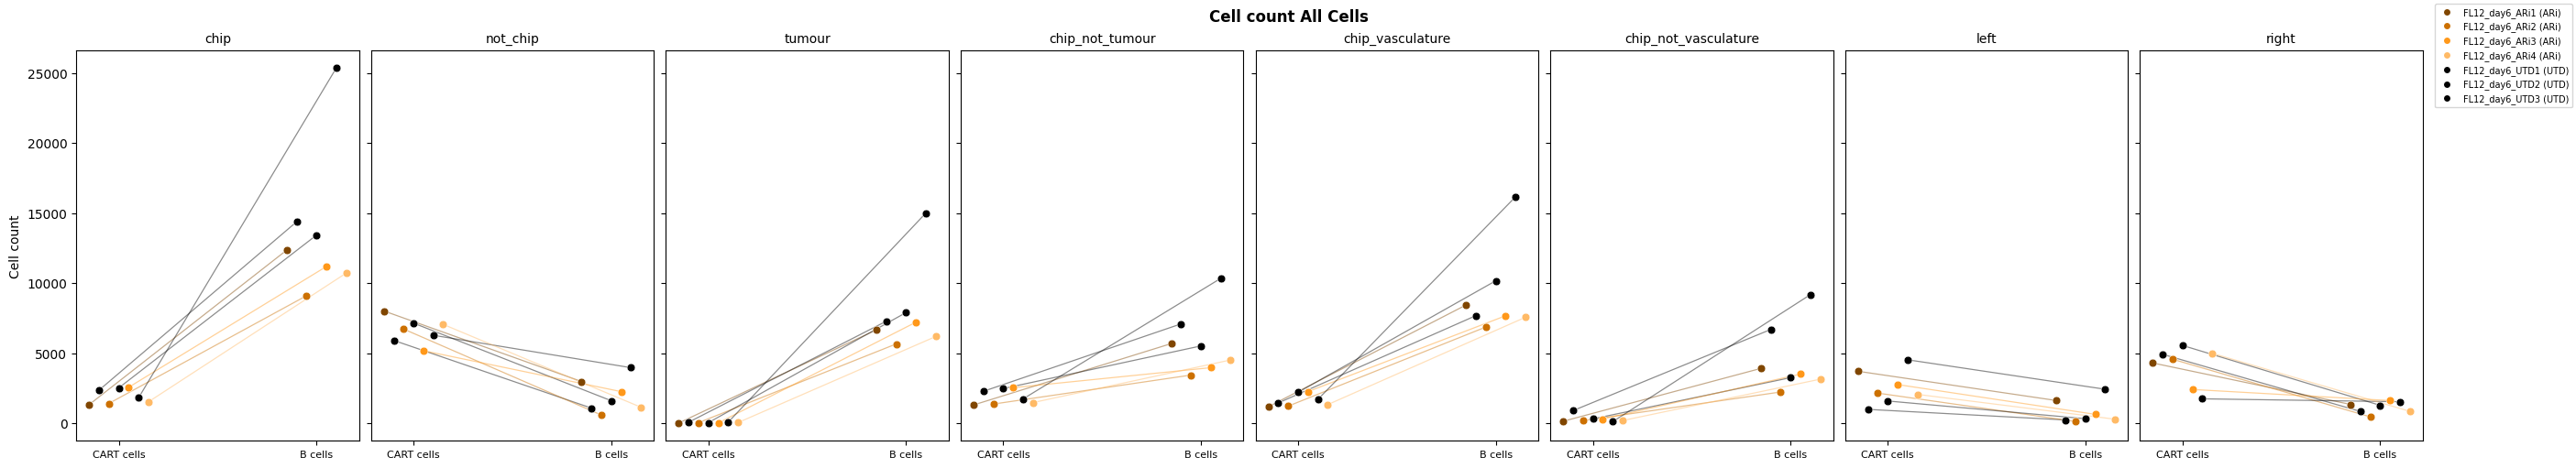

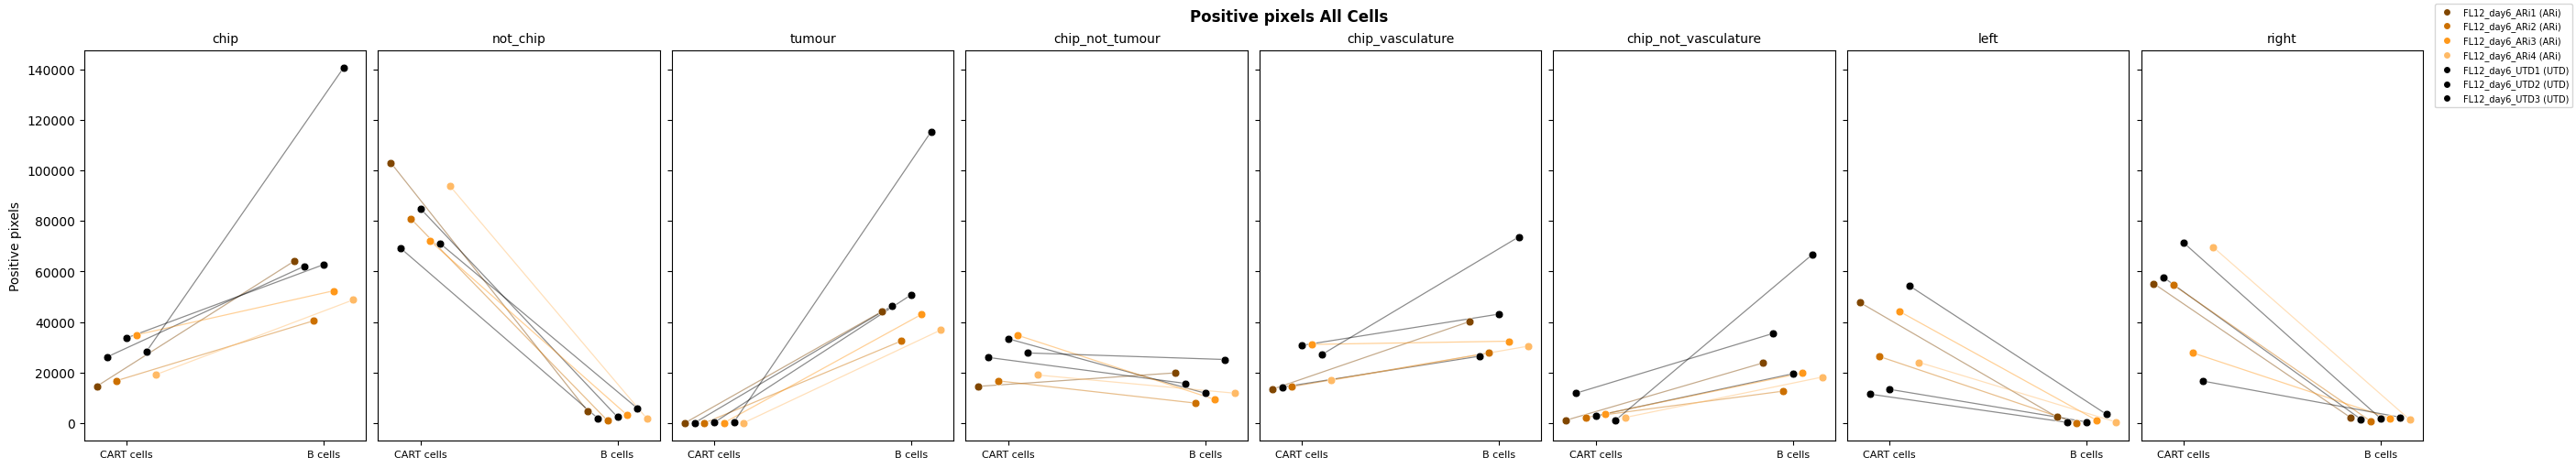

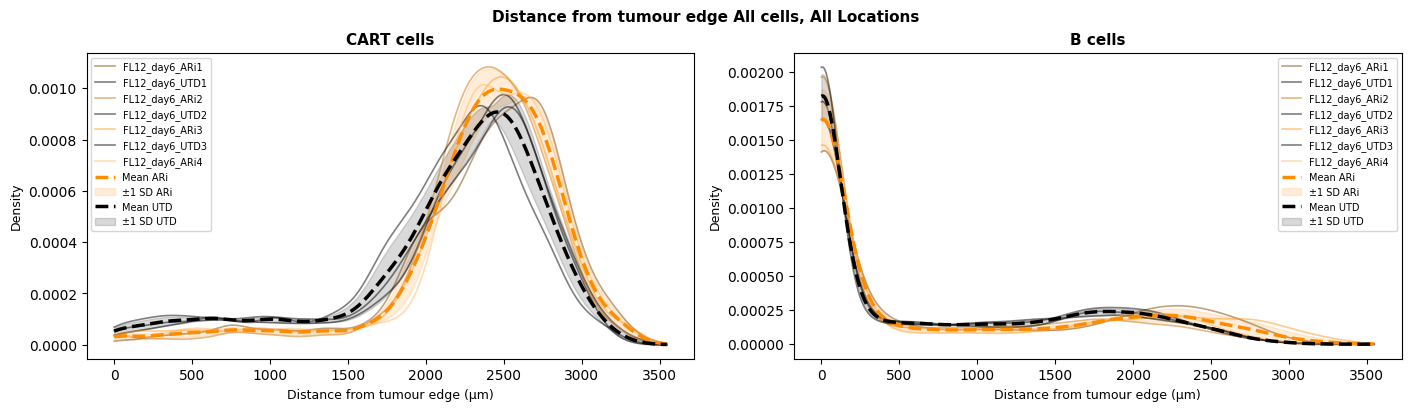

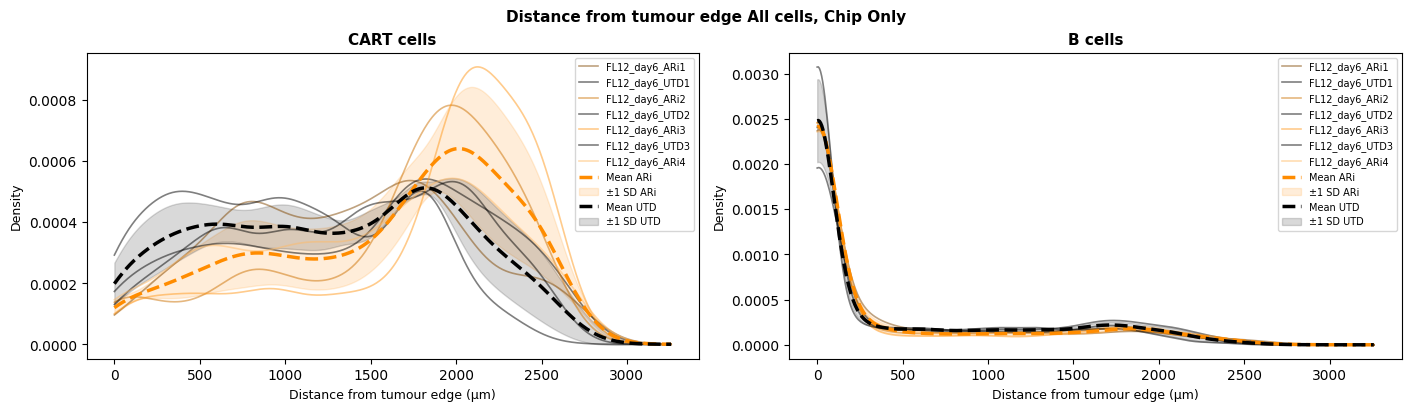

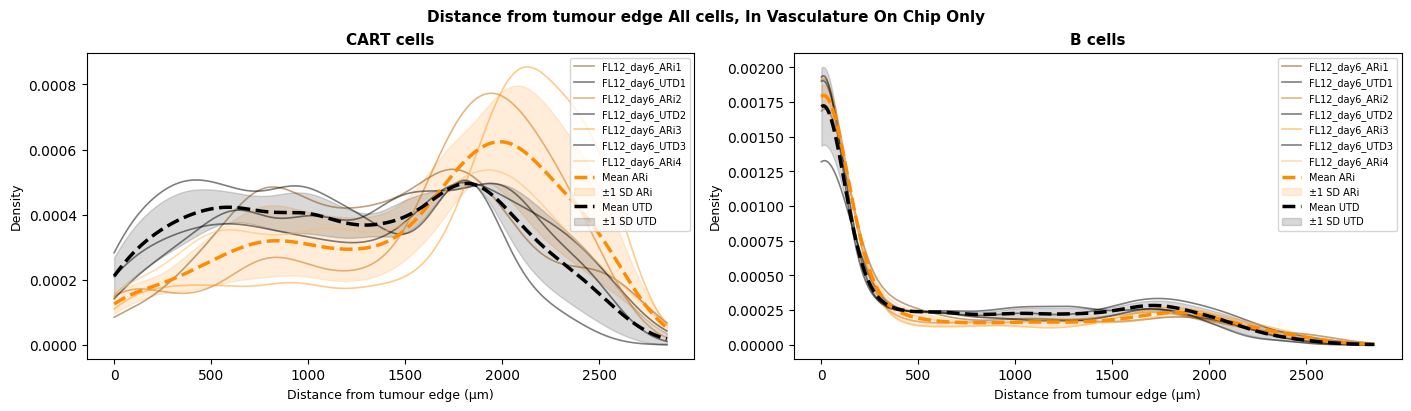

In [ ]:
# 2) Define a palette for each condition
CONDITION_PALETTE = {
    "ARi_day7": "#ff0000",       # red
    "ARi_day6": "#ff8800",       # orange
    "UTD_day6": "#000000",       # blue
    "UTD_day7": "#00cc88",       # teal
}
plot_swarmplots(all_results[(all_results["patient"]=="fl12") & (all_results["day"]==6) ], save_title="fl12_d6", title_suffix = " All Cells")

plot_distance_kde(all_distances[(all_distances["patient"]=="fl12") & (all_distances["day"]==6) ], save_title="fl12_d6_all_cells", title_suffix = " All cells, All Locations")
plot_distance_kde(all_distances[(all_distances["patient"]=="fl12") & (all_distances["day"]==6) & (all_distances["in_chip"]== True) ], save_title="fl12_d6_cells_in_chip", title_suffix = " All cells, Chip Only")
plot_distance_kde(all_distances[(all_distances["patient"]=="fl12") & (all_distances["day"]==6) & (all_distances["in_chip_vasculature"] == True) & (all_distances["in_chip"]== True) ], save_title="fl12_d6_cells_in_chip_AND_in_vasculature", title_suffix = " All cells, In Vasculature On Chip Only")

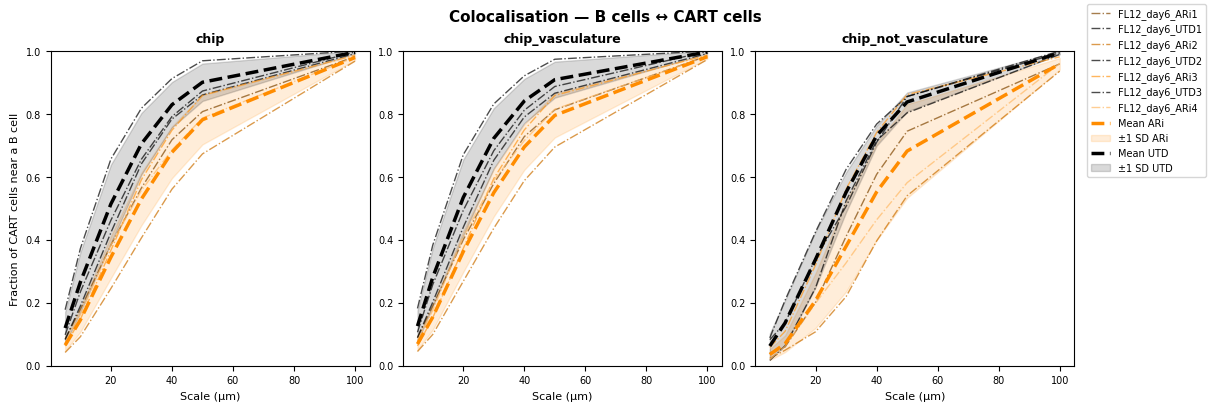

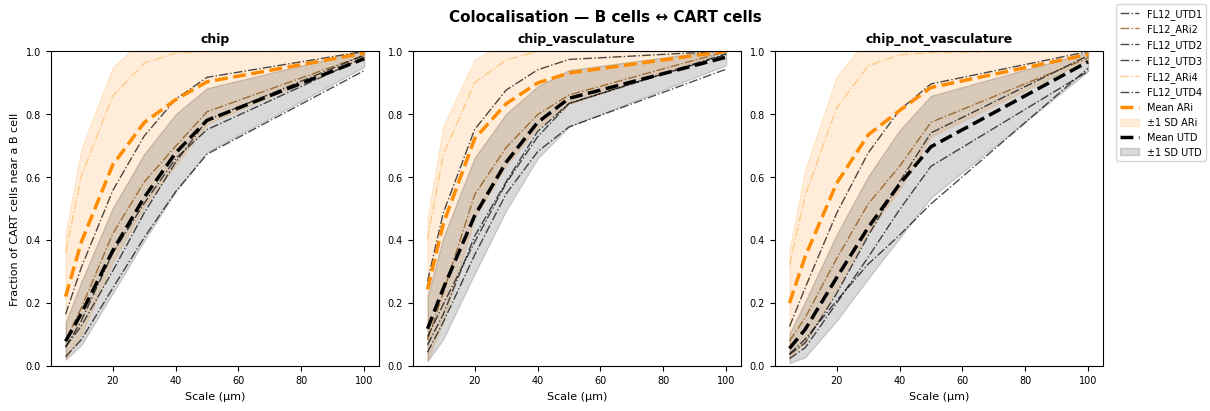

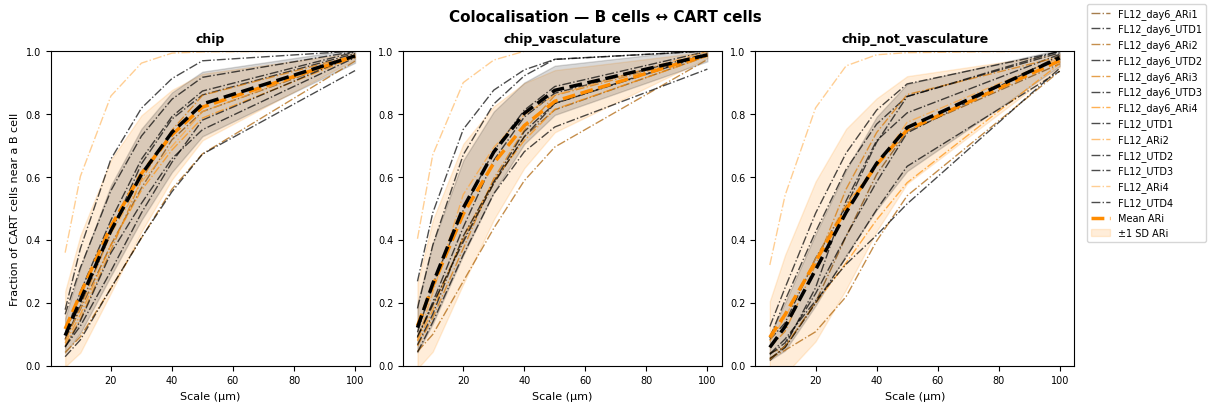

In [ ]:
COLOC_REGIONS = ["chip", "chip_not_vasculature", "chip_vasculature"]

# Show just CART_near_B
plot_colocalisation(coloc_df[(coloc_df["day"] == 6) & (coloc_df["patient"] == "fl12")], methods=["CART_near_B"], save_title="d6_fl12_cart_near_B", plot_regions=["chip", "chip_vasculature", "chip_not_vasculature"])
plot_colocalisation(coloc_df[(coloc_df["day"] == 7) & (coloc_df["patient"] == "fl12")], methods=["CART_near_B"], save_title="d7_fl12_cart_near_B", plot_regions=["chip", "chip_vasculature", "chip_not_vasculature"])
plot_colocalisation(coloc_df[(coloc_df["patient"] == "fl12")], methods=["CART_near_B"], save_title="fl12_cart_near_B", plot_regions=["chip", "chip_vasculature", "chip_not_vasculature"])

# Show just B_near_CART
# plot_colocalisation(_coloc_sub, methods=["B_near_CART"], plot_regions=COLOC_REGIONS)

# Show just coarse Pearson
# plot_colocalisation(_coloc_sub, methods=["coarse_pearson"], plot_regions=COLOC_REGIONS)

# Show all three methods at once
# plot_colocalisation(_coloc_sub, plot_regions=COLOC_REGIONS)
